# Autoencoders

**DISCLAIMER: This notebook setup to use an A100 on google colab.  If you can only access worse GPUs, you can try lowering the batch_size, however this will have a detrimental effect on one-to-one stitching.**

This notebook contains two example autoencoders, the first trained on MNIST and the second trained on FashionMNIST.  An autoencoder is neural network consisting of two parts: an encoder and a decoder.  As can be seen in the image below, the encoder compresses a given input to code.  This code part of the network is often called the bottleneck.  The decoder takes this code and produces an output.  

<img src="https://miro.medium.com/v2/resize:fit:4800/format:webp/1*44eDEuZBEsmG_TCAKRI3Kw@2x.png" width=500>

The output should be the same as the input and is leart using mean squared error loss:

$$ \mathcal{L} = \| input - output \|^2 $$

Since the bottleneck has a lower dimensionality than the input or output, the learning process forces the network to compress our input in a way that losses a little information as possible.  The more information that is retrained during the encoding, the better our output will be.

# MNIST

## Setup

Import python libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

Are we using a GPU or a CPU?

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Dataset

We will use the MNIST dataset which contains 10,000s of $28 \times 28$ resolution images.

In [3]:
# Load MNIST dataset with normalization
transform = transforms.Compose([
    transforms.ToTensor(),
])

batch_size = 512
mnist_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
mnist_loader = DataLoader(mnist_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 9.91M/9.91M [00:01<00:00, 5.08MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 28.9k/28.9k [00:00<00:00, 65.3kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 1.65M/1.65M [00:06<00:00, 246kB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.28MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



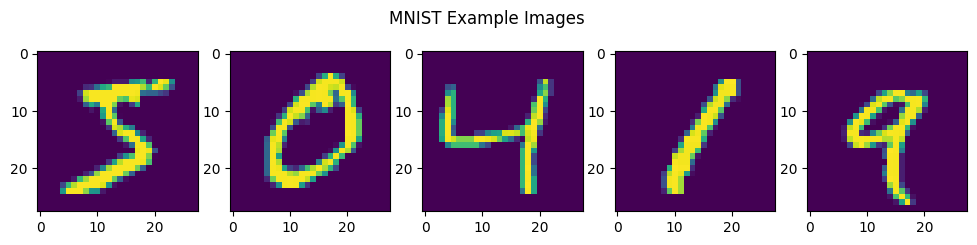

In [4]:
# Plot examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('MNIST Example Images')
ax[0].imshow(mnist_dataset[0][0][0,:,:].numpy())
ax[1].imshow(mnist_dataset[1][0][0,:,:].numpy())
ax[2].imshow(mnist_dataset[2][0][0,:,:].numpy())
ax[3].imshow(mnist_dataset[3][0][0,:,:].numpy())
ax[4].imshow(mnist_dataset[4][0][0,:,:].numpy())


## Neural Network



We will be using a simple AutoEncoder here.  This network uses a combination of linear and convolution layers to compress an image into a smaller respresentation, then uses a decoder to network to reconstruct the image from this compressed representation.

In [5]:
class Autoencoder(nn.Module):
    def __init__(self, in_channels, img_size, latent_dim=128):
        super(Autoencoder, self).__init__()

        # What is the dimension of our image after going through the encoder?
        downsampled_size = int(img_size / 4)

        # Encoder
        self.encoder = nn.Sequential(
            # First conv block
            nn.Conv2d(in_channels, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 14x14

            # Second conv block
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 7x7

            # Flatten and dense layers
            nn.Flatten(),
            nn.Linear(512 * downsampled_size * downsampled_size, 512),
            nn.ReLU(),
            nn.Linear(512, latent_dim),
            nn.BatchNorm1d(latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            # Dense layers
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 32 * downsampled_size * downsampled_size),
            nn.ReLU(),
            nn.Linear(32 * downsampled_size * downsampled_size, 32 * downsampled_size * downsampled_size),
            nn.ReLU(),
            nn.Linear(32 * downsampled_size * downsampled_size, 32 * downsampled_size * downsampled_size),
            nn.ReLU(),
            nn.Linear(32 * downsampled_size * downsampled_size, 256 * downsampled_size * downsampled_size),
            nn.ReLU(),
            nn.Linear(256 * downsampled_size * downsampled_size, 512 * downsampled_size * downsampled_size),
            nn.ReLU(),

            # Reshape layer
            nn.Unflatten(1, (512, downsampled_size, downsampled_size)),

            # First conv transpose block
            nn.ConvTranspose2d(512, 512, kernel_size=2, stride=2),  # 14x14
            nn.ReLU(),
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(),

            # Second conv transpose block
            nn.ConvTranspose2d(256, 256, kernel_size=2, stride=2),  # 28x28
            nn.ReLU(),
            nn.Conv2d(256, in_channels, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction


## Training

Train our autoencoder to reconstruct MNIST images.

In [6]:
def train_autoencoder(model, dataloader, epochs, learning_rate):

    # Initialize loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    loss_history = []
    for epoch in range(epochs):
        total_loss = 0
        for data in dataloader:
            # Sample data from dataset
            img, _ = data
            img = img.to(device)

            # Forward pass
            output = model(img)
            loss = criterion(output, img)

            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        # Log the loss for this epoch
        avg_loss = total_loss/len(dataloader)
        loss_history.append(avg_loss)
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')

    return model, loss_history

In [7]:
# Hyperparameters
epochs=25
learning_rate=1e-4

# Initialize model
img_size = 28
in_channels = 1
bottleneck_size = 128
mnist_model = Autoencoder(in_channels, img_size, bottleneck_size).to(device)

# Train model
mnist_model, loss_history = train_autoencoder(mnist_model, mnist_loader, epochs, learning_rate)

Epoch [1/25], Loss: 0.083525
Epoch [2/25], Loss: 0.049111
Epoch [3/25], Loss: 0.032137
Epoch [4/25], Loss: 0.024167
Epoch [5/25], Loss: 0.020495
Epoch [6/25], Loss: 0.017902
Epoch [7/25], Loss: 0.016081
Epoch [8/25], Loss: 0.014464
Epoch [9/25], Loss: 0.013642
Epoch [10/25], Loss: 0.012243
Epoch [11/25], Loss: 0.011717
Epoch [12/25], Loss: 0.010941
Epoch [13/25], Loss: 0.010574
Epoch [14/25], Loss: 0.009971
Epoch [15/25], Loss: 0.009518
Epoch [16/25], Loss: 0.009154
Epoch [17/25], Loss: 0.008857
Epoch [18/25], Loss: 0.008614
Epoch [19/25], Loss: 0.008324
Epoch [20/25], Loss: 0.008127
Epoch [21/25], Loss: 0.007962
Epoch [22/25], Loss: 0.007603
Epoch [23/25], Loss: 0.007519
Epoch [24/25], Loss: 0.007324
Epoch [25/25], Loss: 0.007215


Text(0.5, 1.0, 'MNIST Training Loss')

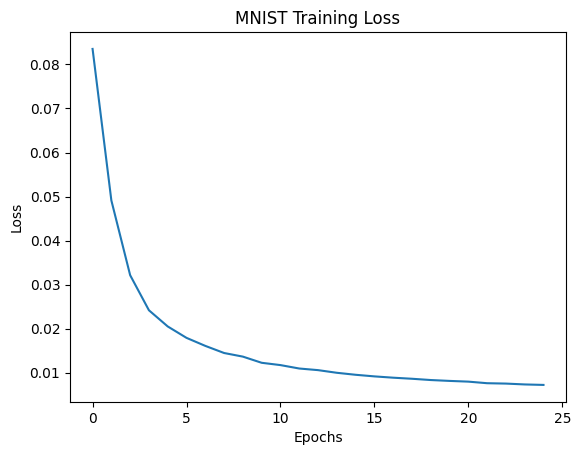

In [8]:
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('MNIST Training Loss')

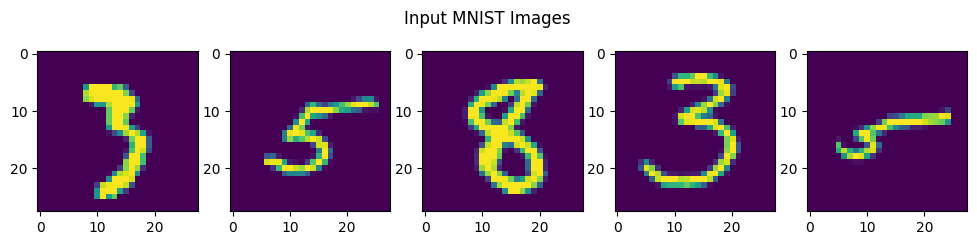

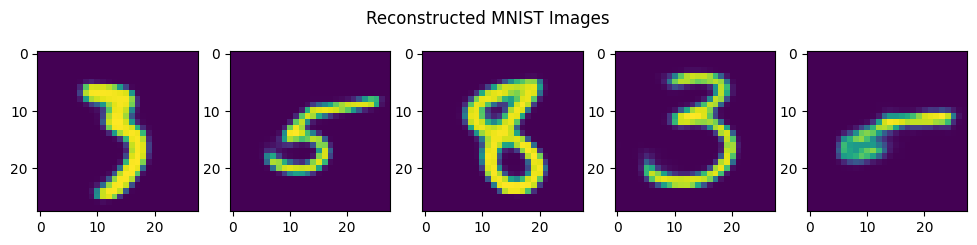

In [9]:
# Sample images
img, _ = next(iter(mnist_loader))

# Plot starting examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('Input MNIST Images')
ax[0].imshow(img[0,0,:,:].cpu().numpy())
ax[1].imshow(img[1,0,:,:].cpu().numpy())
ax[2].imshow(img[2,0,:,:].cpu().numpy())
ax[3].imshow(img[3,0,:,:].cpu().numpy())
ax[4].imshow(img[4,0,:,:].cpu().numpy())
plt.show()

# Run images though the autoencdoer
output = mnist_model(img.to(device))

# Plot reconstructed images
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('Reconstructed MNIST Images')
ax[0].imshow(output[0,0,:,:].detach().cpu().numpy())
ax[1].imshow(output[1,0,:,:].detach().cpu().numpy())
ax[2].imshow(output[2,0,:,:].detach().cpu().numpy())
ax[3].imshow(output[3,0,:,:].detach().cpu().numpy())
ax[4].imshow(output[4,0,:,:].detach().cpu().numpy())
plt.show()

# FashionMNIST

## Dataset

Our second dataset the FashionMNIST dataset.

In [10]:
# Load FashionMNIST dataset with normalization
transform = transforms.Compose([
    transforms.ToTensor(),
])

fashion_dataset = datasets.FashionMNIST(
    root='./data',  # Data will be downloaded to this directory
    train=True,     # Specify that we want the training dataset
    download=True,  # Download the dataset if it's not already downloaded
    transform=transform
)
fashion_test_dataset = datasets.FashionMNIST(
    root='./data',  # Data will be downloaded to this directory
    train=False,     # Specify that we want the training dataset
    download=True,  # Download the dataset if it's not already downloaded
    transform=transform
)
fashion_loader = DataLoader(fashion_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
fashion_test_loader = DataLoader(fashion_test_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.6MB/s]


Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]


Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 3.21MB/s]


Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 6.98MB/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



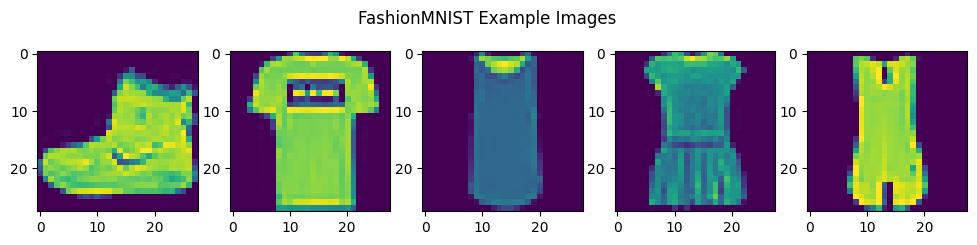

In [11]:
# Plot examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('FashionMNIST Example Images')
ax[0].imshow(fashion_dataset[0][0][0,:,:].numpy())
ax[1].imshow(fashion_dataset[1][0][0,:,:].numpy())
ax[2].imshow(fashion_dataset[2][0][0,:,:].numpy())
ax[3].imshow(fashion_dataset[3][0][0,:,:].numpy())
ax[4].imshow(fashion_dataset[4][0][0,:,:].numpy())


## Training

Now we will train another autoencoder on the FashionMNIST dataset.

In [12]:
# Initialize model, loss, and optimizer
img_size = 28
in_channels = 1
fashion_model = Autoencoder(in_channels, img_size, bottleneck_size).to(device)

# Train model
fashion_model, loss_history = train_autoencoder(fashion_model, fashion_loader, epochs, learning_rate)

Epoch [1/25], Loss: 0.076183
Epoch [2/25], Loss: 0.031922
Epoch [3/25], Loss: 0.025093
Epoch [4/25], Loss: 0.022649
Epoch [5/25], Loss: 0.021405
Epoch [6/25], Loss: 0.019898
Epoch [7/25], Loss: 0.018621
Epoch [8/25], Loss: 0.017429
Epoch [9/25], Loss: 0.016694
Epoch [10/25], Loss: 0.015920
Epoch [11/25], Loss: 0.015370
Epoch [12/25], Loss: 0.015012
Epoch [13/25], Loss: 0.014755
Epoch [14/25], Loss: 0.014627
Epoch [15/25], Loss: 0.013998
Epoch [16/25], Loss: 0.013594
Epoch [17/25], Loss: 0.013243
Epoch [18/25], Loss: 0.012936
Epoch [19/25], Loss: 0.012826
Epoch [20/25], Loss: 0.012428
Epoch [21/25], Loss: 0.012348
Epoch [22/25], Loss: 0.012088
Epoch [23/25], Loss: 0.011785
Epoch [24/25], Loss: 0.011760
Epoch [25/25], Loss: 0.011487


Text(0.5, 1.0, 'FashionMNIST Training Loss')

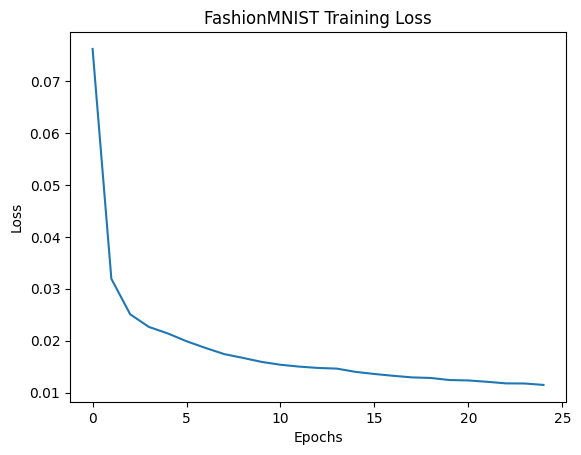

In [13]:
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('FashionMNIST Training Loss')

Here we plot input images, and the image reconstructed by the autoencoder.

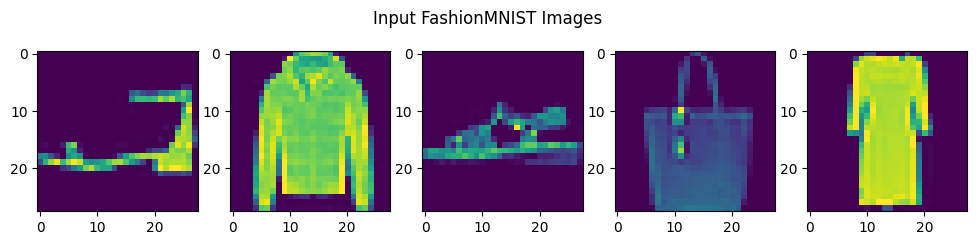

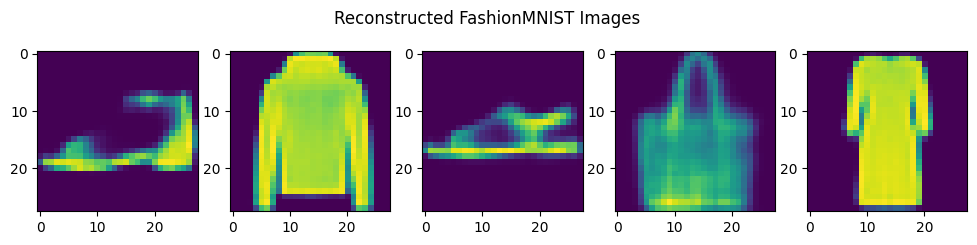

In [14]:
# Sample FashionMNIST images
img, _ = next(iter(fashion_loader))

# Plot starting examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('Input FashionMNIST Images')
ax[0].imshow(img[0,0,:,:].cpu().numpy())
ax[1].imshow(img[1,0,:,:].cpu().numpy())
ax[2].imshow(img[2,0,:,:].cpu().numpy())
ax[3].imshow(img[3,0,:,:].cpu().numpy())
ax[4].imshow(img[4,0,:,:].cpu().numpy())
plt.show()

# Run images though the autoencdoer
output = fashion_model(img.to(device))

# Plot reconstructed images
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('Reconstructed FashionMNIST Images')
ax[0].imshow(output[0,0,:,:].detach().cpu().numpy())
ax[1].imshow(output[1,0,:,:].detach().cpu().numpy())
ax[2].imshow(output[2,0,:,:].detach().cpu().numpy())
ax[3].imshow(output[3,0,:,:].detach().cpu().numpy())
ax[4].imshow(output[4,0,:,:].detach().cpu().numpy())

# Stitching

## Neural Network

Define a stitch which is a simple 1d convolution layer which will connect two sub-networks

In [15]:
class Stitch(nn.Module):

    def __init__(self, n_dims):
        super(Stitch, self).__init__()
        self.bn1 = nn.BatchNorm2d(n_dims)
        self.conv = nn.Conv2d(n_dims, n_dims, kernel_size=1, stride=1, padding=0)
        self.bn2 = nn.BatchNorm2d(n_dims)

    def forward(self, x):
        out = self.bn1(x)
        out = self.conv(out)
        out = self.bn2(out)
        return out

In [16]:
class StichedAutoencoder(nn.Module):

    def __init__(self, encoder, decoder, bottleneck_size):
        super(StichedAutoencoder, self).__init__()
        self.bottleneck_size = bottleneck_size
        self.encoder = encoder
        self.stitch = Stitch(self.bottleneck_size)
        self.decoder = decoder

    def forward(self, x):
        x = self.encoder(x).view(-1,self.bottleneck_size,1,1)
        stitch_x = self.stitch(x).view(-1,self.bottleneck_size)
        x = self.decoder(stitch_x)
        return x, stitch_x

fashion_to_mnist_model = StichedAutoencoder(fashion_model.encoder, mnist_model.decoder, bottleneck_size).to(device)

# Put top model into train mode so that bn and dropout perform in training mode
fashion_to_mnist_model.train()
# Freeze the top model
fashion_to_mnist_model.requires_grad_(False)
# Un-Freeze the stitch layer
for name, param in fashion_to_mnist_model.stitch.named_parameters():
    param.requires_grad_(True)

## One-to-One Stitch Training

In this method, we first encode batches of FashionMNIST and MNIST images into their respective autoencoder's latent space (bottleneck).  The bottleneck points for the FashionMNIST dataset are then run through the stitch which contains the only trainable parameters of the model.  For every point post stitch we try to assign a single point in the MNIST bottleneck.  Our goal is to assign corresponding points between the two latent spaces, minimizing the distance between these matched points. This mapping challenge is known as the linear sum assignment problem, which can be efficiently solved using SciPy. Essentially, we're evaluating how well the FashionMNIST points align with MNIST points.

In [17]:
from scipy.optimize import linear_sum_assignment

# define the loss function and the optimiser
criterion = nn.MSELoss()
optimiser = optim.SGD(fashion_to_mnist_model.parameters(), lr=1e-5, momentum=0.9, weight_decay=0.01)

stitch_train_epochs = 25
loss_history = []
for epoch in range(stitch_train_epochs):
    running_loss = 0.0
    for data in fashion_loader:

        # get data and put it on the GPU
        inputs = data[0]
        targets = next(iter(mnist_loader))[0]
        inputs = inputs.to(device)
        targets = targets.to(device)

        # zero the parameter gradients
        optimiser.zero_grad()

        # forward + loss + backward + optimise (update weights)
        outputs, stitch_output = fashion_to_mnist_model(inputs)
        with torch.no_grad():
            target_latent = mnist_model.encoder(targets)


        # Calculate L2 distance between every set of points
        cost_matrix = torch.sum(((target_latent.view(batch_size,1,bottleneck_size) - stitch_output.view(1,batch_size,bottleneck_size)) ** 2), dim=2)

        # Hungarian Algorithm
        row_indices, col_indices = linear_sum_assignment(cost_matrix.detach().cpu().numpy())

        # Convert indices back to PyTorch tensors
        row_indices = torch.from_numpy(row_indices)
        col_indices = torch.from_numpy(col_indices)

        # Get the selected elements from the original matrix
        selected_elements = cost_matrix[row_indices, col_indices]

        # Calculate total cost
        total_cost = selected_elements.sum()
        loss = total_cost
        loss.backward()
        optimiser.step()

        # keep track of the loss this epoch
        running_loss += loss.item()

    # Log training losses
    avg_loss = running_loss / len(fashion_loader)
    loss_history.append(avg_loss)
    print(f'Epoch [{epoch+1}/{stitch_train_epochs}], Loss: {avg_loss:.6f}')

Epoch [1/25], Loss: 42999.700020
Epoch [2/25], Loss: 37285.493757
Epoch [3/25], Loss: 35891.435597
Epoch [4/25], Loss: 34932.759415
Epoch [5/25], Loss: 34389.846989
Epoch [6/25], Loss: 34041.230569
Epoch [7/25], Loss: 33796.182125
Epoch [8/25], Loss: 33626.091313
Epoch [9/25], Loss: 33392.491653
Epoch [10/25], Loss: 33361.404915
Epoch [11/25], Loss: 33147.620927
Epoch [12/25], Loss: 33203.336739
Epoch [13/25], Loss: 33046.511919
Epoch [14/25], Loss: 32970.151275
Epoch [15/25], Loss: 32883.105586
Epoch [16/25], Loss: 32793.517995
Epoch [17/25], Loss: 32706.870109
Epoch [18/25], Loss: 32745.662193
Epoch [19/25], Loss: 32709.671241
Epoch [20/25], Loss: 32566.611428
Epoch [21/25], Loss: 32596.814720
Epoch [22/25], Loss: 32500.543770
Epoch [23/25], Loss: 32542.699336
Epoch [24/25], Loss: 32417.325871
Epoch [25/25], Loss: 32430.655866


Text(0.5, 1.0, 'FashionMNIST to MNIST Training Loss')

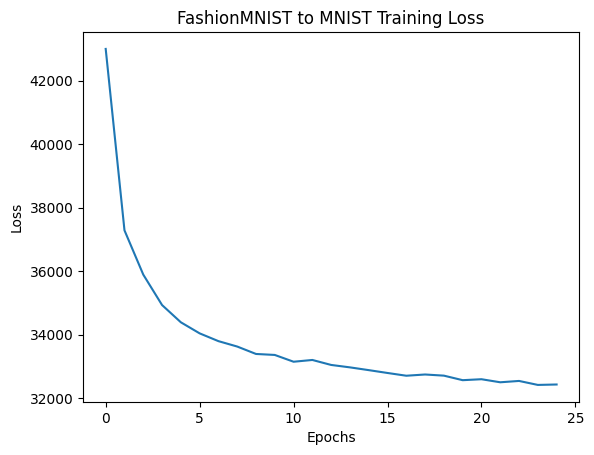

In [18]:
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('FashionMNIST to MNIST Training Loss')

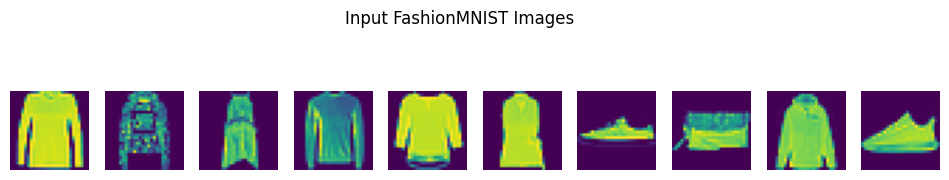

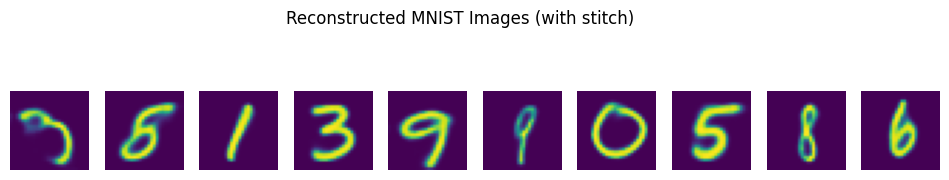

In [19]:
# Sample FashionMNIST images
data = next(iter(fashion_test_loader))
inputs = data[0]

# Plot starting examples
total_images = 10
fig, ax= plt.subplots(1, total_images, figsize=(12, 2.5))
fig.suptitle('Input FashionMNIST Images')
for i in range(total_images):
    ax[i].imshow(np.transpose(inputs[i].cpu().numpy(), (1,2,0)))
    ax[i].axis('off')
plt.show()

# Run images though the autoencdoer
output, _ = fashion_to_mnist_model(inputs.to(device))


# Plot reconstructed images
fig, ax= plt.subplots(1, total_images, figsize=(12, 2.5))
fig.suptitle('Reconstructed MNIST Images (with stitch)')
for i in range(total_images):
    ax[i].imshow(output[i,0,:,:].detach().cpu().numpy())
    ax[i].axis('off')
plt.show()


## Dataset

For training the stitch we will match FashionMNIST to MNIST images in a one-to-one fashion.  Classes should also match up.  For instance, images of shoes in FashionMNIST should always be mapped images of 0's in MNIST.

In [20]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets, transforms
import numpy as np

class MNISTFashionDataset(Dataset):
    def __init__(self, mnist_root='./data', fashion_root='./data', train=True):
        # Load datasets
        self.mnist = datasets.MNIST(root=mnist_root, train=train, download=True,
                                  transform=transforms.ToTensor())
        self.fashion = datasets.FashionMNIST(root=fashion_root, train=train, download=True,
                                    transform=transforms.ToTensor())

        # Get indices for each class
        self.mnist_indices = self._get_class_indices(self.mnist)
        self.fashion_indices = self._get_class_indices(self.fashion)

        # Calculate number of samples per class to use
        self.samples_per_class = min(
            min(len(indices) for indices in self.mnist_indices),
            min(len(indices) for indices in self.fashion_indices)
        )

        # Restict lists of indicies to be the same size
        self.mnist_indices = [lst[:self.samples_per_class] + [] * (self.samples_per_class - len(lst[:self.samples_per_class])) for lst in self.mnist_indices]
        self.mnist_indices = sum(self.mnist_indices, [])
        self.fashion_indices = [lst[:self.samples_per_class] + [] * (self.samples_per_class - len(lst[:self.samples_per_class])) for lst in self.fashion_indices]
        self.fashion_indices = sum(self.fashion_indices, [])

    def _get_class_indices(self, dataset):
        indices = [[] for _ in range(10)]
        for idx, (_, label) in enumerate(dataset):
            indices[label].append(idx)
        return indices

    def __getitem__(self, idx):

        # Get MNIST sample
        mnist_idx = self.mnist_indices[idx]
        mnist_img, mnist_label = self.mnist[mnist_idx]

        # Get corresponding fashionMNIST sample
        fashion_idx = self.fashion_indices[idx]
        fashion_img, fashion_label = self.fashion[fashion_idx]

        return {
            'mnist_image': mnist_img,
            'mnist_label': mnist_label,
            'fashion_image': fashion_img,
            'fashion_label': fashion_label
        }

    def __len__(self):
        return len(self.mnist_indices)

combined_dataset = MNISTFashionDataset()
combined_loader = DataLoader(combined_dataset, batch_size=batch_size, shuffle=True)

Display matched up MNIST and FashionMNIST images.

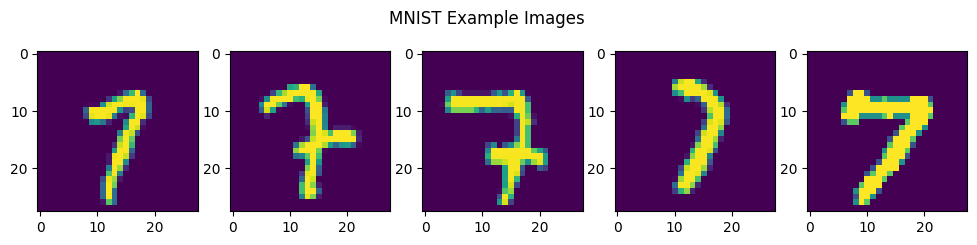

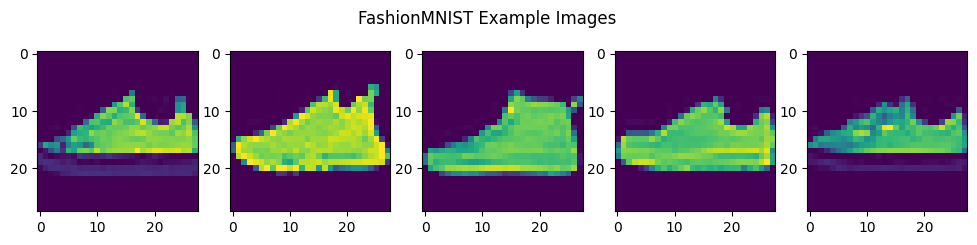

In [21]:
# Plot examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('MNIST Example Images')
for i in range(5):
    ax[i].imshow(combined_dataset[40000+i]['mnist_image'][0,:,:].numpy())
plt.show()

# Plot examples
fig, ax= plt.subplots(1, 5, figsize=(12, 2.5))
fig.suptitle('FashionMNIST Example Images')
for i in range(5):
    ax[i].imshow(combined_dataset[40000+i]['fashion_image'][0,:,:].numpy())
plt.show()



## Cluster-to-Cluster Stitch Training

Train a stitch between the FashionMNIST encoder and the MNIST decoder.  In this case, match classes in one dataset to classes in the other.  Each image in FashionMNIST is assigned to an MNIST image according to the following mappings:

<u>**FashionMNIST to MNIST Mappings**</u>

T-shirt/top $\rightarrow$ 0

Trouser $\rightarrow$ 1

Pullover $\rightarrow$ 2

Dress $\rightarrow$ 3

Coat $\rightarrow$ 4

Sandal $\rightarrow$ 5

Shirt $\rightarrow$ 6

Sneaker $\rightarrow$ 7

Bag $\rightarrow$ 8

Ankle boot $\rightarrow$ 9

In [22]:
fashion_to_mnist_model_2 = StichedAutoencoder(fashion_model.encoder, mnist_model.decoder, bottleneck_size).to(device)

# Put top model into train mode so that bn and dropout perform in training mode
fashion_to_mnist_model_2.train()
# Freeze the top model
fashion_to_mnist_model_2.requires_grad_(False)
# Un-Freeze the stitch layer
for name, param in fashion_to_mnist_model_2.stitch.named_parameters():
    param.requires_grad_(True)

In [23]:
# define the loss function and the optimiser
criterion = nn.MSELoss()
optimiser = optim.SGD(fashion_to_mnist_model_2.parameters(), lr=1e-2, momentum=0.9, weight_decay=0.01)

stitch_train_epochs = 20
loss_history = []
for epoch in range(stitch_train_epochs):
    running_loss = 0.0
    for data in combined_loader:

        # get data and put it on the GPU
        inputs, targets = data['fashion_image'], data['mnist_image']
        inputs = inputs.to(device)
        targets = targets.to(device)

        # zero the parameter gradients
        optimiser.zero_grad()

        # forward + loss + backward + optimise (update weights)
        outputs, _ = fashion_to_mnist_model_2(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimiser.step()

        # keep track of the loss this epoch
        running_loss += loss.item()

    # Log training losses
    avg_loss = running_loss / len(combined_loader)
    loss_history.append(avg_loss)
    print(f'Epoch [{epoch+1}/{stitch_train_epochs}], Loss: {avg_loss:.6f}')

Epoch [1/20], Loss: 0.090069
Epoch [2/20], Loss: 0.076006
Epoch [3/20], Loss: 0.070327
Epoch [4/20], Loss: 0.067277
Epoch [5/20], Loss: 0.065492
Epoch [6/20], Loss: 0.064415
Epoch [7/20], Loss: 0.063741
Epoch [8/20], Loss: 0.063318
Epoch [9/20], Loss: 0.063029
Epoch [10/20], Loss: 0.062846
Epoch [11/20], Loss: 0.062750
Epoch [12/20], Loss: 0.062673
Epoch [13/20], Loss: 0.062654
Epoch [14/20], Loss: 0.062650
Epoch [15/20], Loss: 0.062666
Epoch [16/20], Loss: 0.062713
Epoch [17/20], Loss: 0.062754
Epoch [18/20], Loss: 0.062799
Epoch [19/20], Loss: 0.062879
Epoch [20/20], Loss: 0.062972


Text(0.5, 1.0, 'FashionMNIST to MNIST Training Loss')

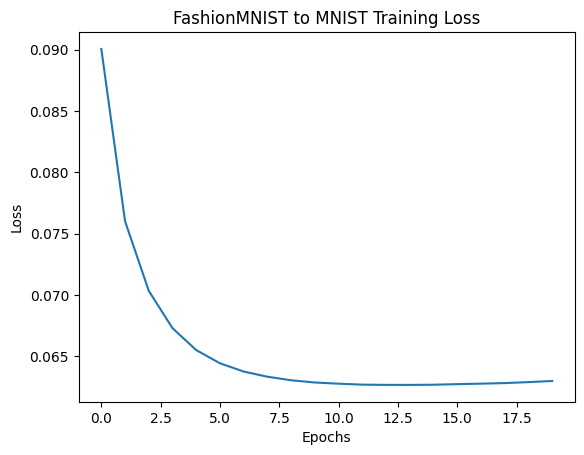

In [24]:
plt.plot(loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('FashionMNIST to MNIST Training Loss')

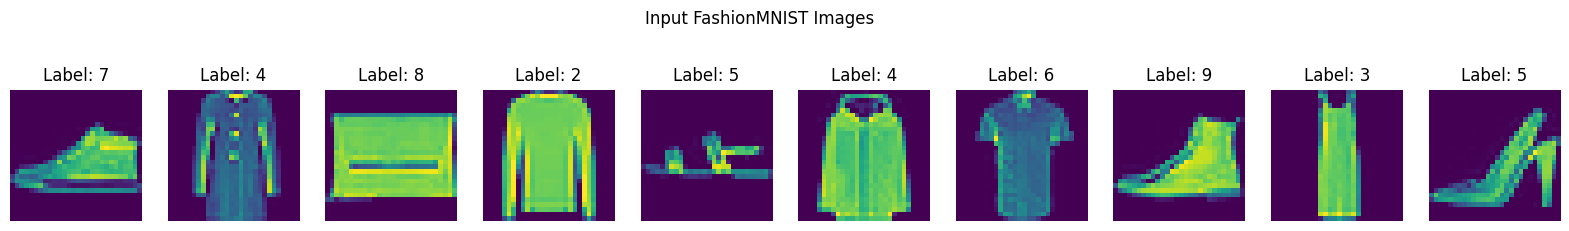

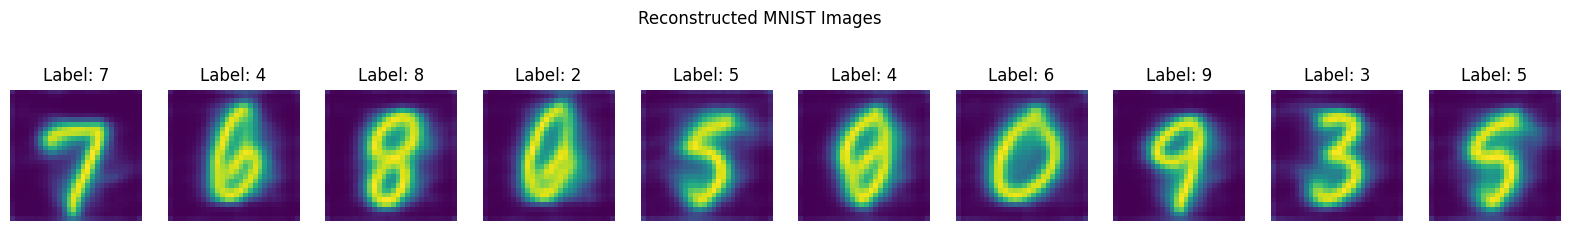

In [25]:
# Sample FashionMNIST images
data = next(iter(fashion_test_loader))
inputs, labels = data[0], data[1]

# Plot starting examples
fig, ax= plt.subplots(1, 10, figsize=(20, 3))
fig.suptitle('Input FashionMNIST Images')
for i in range(10):
    ax[i].imshow(np.transpose(inputs[i].cpu().numpy(), (1,2,0)))
    ax[i].set_title("Label: " + str(labels[i].item()))
    ax[i].axis('off')
plt.show()

# Run images though the autoencdoer
output, _ = fashion_to_mnist_model_2(inputs.to(device))

# Plot reconstructed images
fig, ax= plt.subplots(1, 10, figsize=(20, 3))
fig.suptitle('Reconstructed MNIST Images')
for i in range(10):
    ax[i].imshow(output[i,0,:,:].detach().cpu().numpy())
    ax[i].set_title("Label: " + str(labels[i].item()))
    ax[i].axis('off')
plt.show()

# Principle Component Analysis

Let's try to cluster bottleneck features in each autoencoder

In [26]:
colors = {0:'red', 1:'orange', 2:'yellow', 3: 'yellowgreen', 4: 'lime', 5: 'cyan', 6: 'blue', 7: 'indigo', 8: 'plum', 9: 'black'}

In [27]:
mnist_bottleneck_points = np.zeros((0, bottleneck_size))
mnist_labels = np.zeros(0)
for data in mnist_loader:
    # Sample data from dataset
    img, labels = data
    bn = mnist_model.encoder(img.to(device))
    mnist_bottleneck_points = np.concatenate([mnist_bottleneck_points, bn.detach().cpu().numpy()], axis=0)
    mnist_labels = np.concatenate([mnist_labels, labels.numpy()], axis=0)


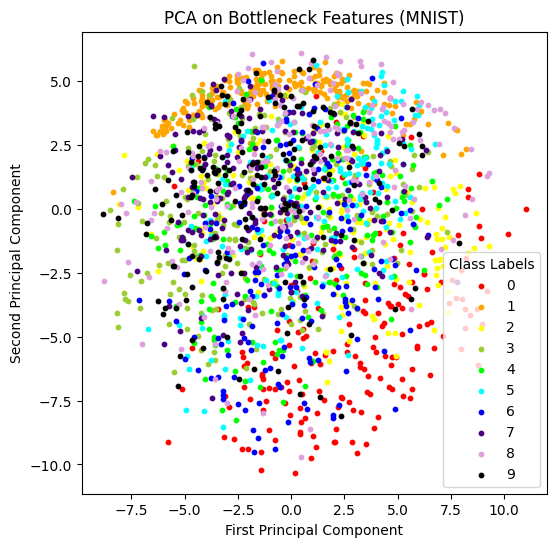

In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA
pca = PCA(n_components=2)
total_points = 2000
X_pca = pca.fit_transform(mnist_bottleneck_points[:total_points])

# Plot the results
plt.figure(figsize=(6, 6))
plt.title('PCA on Bottleneck Features (MNIST)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

# Add points for each class
total_classes = 10
for cls in range(total_classes):
    p = X_pca[mnist_labels[:total_points] == cls]
    plt.scatter(p[:,0], p[:,1], c=colors[cls], s=10, label=str(int(cls)))

plt.legend(title='Class Labels')

In [29]:
fashion_bottleneck_points = np.zeros((0, bottleneck_size))
fashion_labels = np.zeros(0)
for data in fashion_loader:
    # Sample data from dataset
    img, labels = data
    bn = fashion_model.encoder(img.to(device))
    fashion_bottleneck_points = np.concatenate([fashion_bottleneck_points, bn.detach().cpu().numpy()], axis=0)
    fashion_labels = np.concatenate([fashion_labels, labels.numpy()], axis=0)


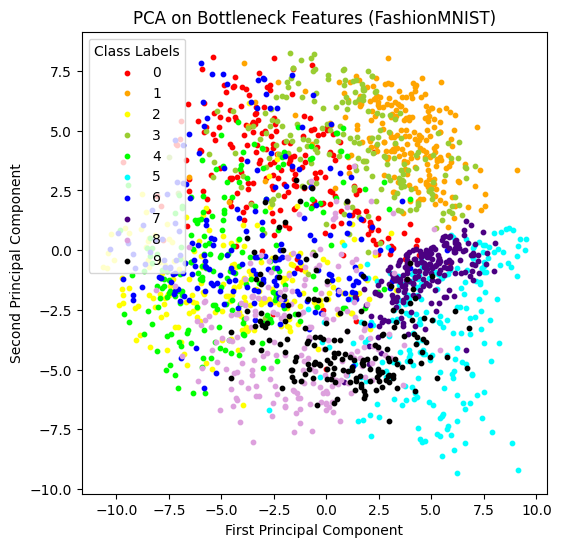

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(fashion_bottleneck_points[:total_points])

# Plot the results
plt.figure(figsize=(6, 6))
plt.title('PCA on Bottleneck Features (FashionMNIST)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

# Add points for each class
total_classes = 10
for cls in range(total_classes):
    p = X_pca[fashion_labels[:total_points] == cls]
    plt.scatter(p[:,0], p[:,1], c=colors[cls], s=10, label=str(int(cls)))

plt.legend(title='Class Labels')

# Save Images

Finally, lets generated some images using our stitched models, and then save the corresponding outputs.

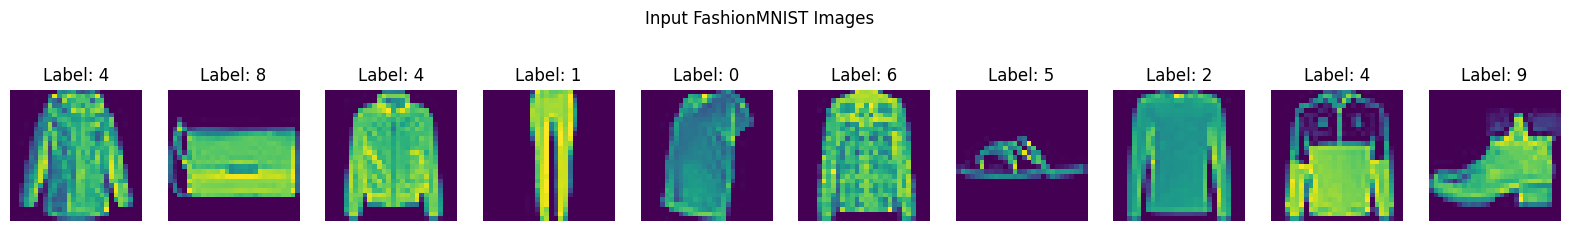

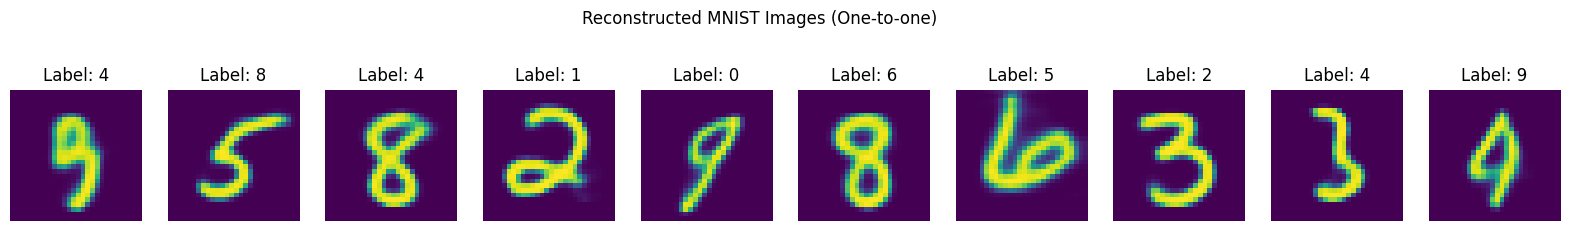

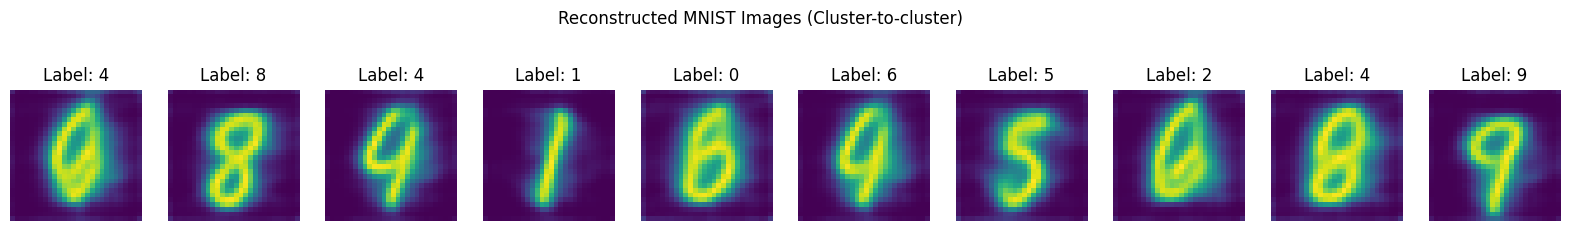

In [32]:
# Sample FashionMNIST images
data = next(iter(fashion_test_loader))
inputs, labels = data[0], data[1]

# Plot starting examples
fig, ax= plt.subplots(1, 10, figsize=(20, 3))
fig.suptitle('Input FashionMNIST Images')
for i in range(10):
    ax[i].imshow(np.transpose(inputs[i].cpu().numpy(), (1,2,0)))
    ax[i].set_title("Label: " + str(labels[i].item()))
    ax[i].axis('off')
plt.show()

# Run images though the autoencdoer
output1, _ = fashion_to_mnist_model(inputs.to(device))

# Plot reconstructed images
fig, ax= plt.subplots(1, 10, figsize=(20, 3))
fig.suptitle('Reconstructed MNIST Images (One-to-one)')
for i in range(10):
    ax[i].imshow(output1[i,0,:,:].detach().cpu().numpy())
    ax[i].set_title("Label: " + str(labels[i].item()))
    ax[i].axis('off')
plt.show()

# Run images though the autoencdoer
output2, _ = fashion_to_mnist_model_2(inputs.to(device))

# Plot reconstructed images
fig, ax= plt.subplots(1, 10, figsize=(20, 3))
fig.suptitle('Reconstructed MNIST Images (Cluster-to-cluster)')
for i in range(10):
    ax[i].imshow(output2[i,0,:,:].detach().cpu().numpy())
    ax[i].set_title("Label: " + str(labels[i].item()))
    ax[i].axis('off')
plt.show()

In [33]:
import torch
import torchvision.utils as vutils
import os

def save_tensor_as_images(tensor, filename_root, output_dir='output_dir', normalize=True):
    """
    Save a PyTorch tensor of images as individual PNG files.

    Args:
    - tensor (torch.Tensor): Input tensor of shape (N, C, H, W)
    - output_dir (str): Directory to save images
    - normalize (bool): Normalize images to [0, 1] range if True
    """
    os.makedirs(output_dir, exist_ok=True)

    # Handle both grayscale and RGB tensors
    if tensor.dim() == 4:
        for i in range(tensor.size(0)):
            img = tensor[i]
            if normalize:
                img = (img - img.min()) / (img.max() - img.min())
            vutils.save_image(img, os.path.join(output_dir, filename_root + f'_{i}.png'))

In [34]:
save_tensor_as_images(torch.clamp(inputs[:32].detach().cpu(), 0, 1), 'in')
save_tensor_as_images(torch.clamp(output1[:32].detach().cpu(), 0, 1), 'out_one_to_one')
save_tensor_as_images(torch.clamp(output2[:32].detach().cpu(), 0, 1), 'out_cluster_to_cluster')

In [35]:
!zip -r /content/outputs.zip /content/output_dir

  adding: content/output_dir/ (stored 0%)
  adding: content/output_dir/out_one_to_one_27.png (stored 0%)
  adding: content/output_dir/out_cluster_to_cluster_13.png (stored 0%)
  adding: content/output_dir/out_cluster_to_cluster_15.png (stored 0%)
  adding: content/output_dir/in_19.png (stored 0%)
  adding: content/output_dir/in_30.png (stored 0%)
  adding: content/output_dir/out_cluster_to_cluster_1.png (stored 0%)
  adding: content/output_dir/in_21.png (stored 0%)
  adding: content/output_dir/out_cluster_to_cluster_24.png (stored 0%)
  adding: content/output_dir/out_one_to_one_30.png (stored 0%)
  adding: content/output_dir/out_one_to_one_28.png (stored 0%)
  adding: content/output_dir/out_one_to_one_24.png (stored 0%)
  adding: content/output_dir/out_cluster_to_cluster_26.png (stored 0%)
  adding: content/output_dir/out_one_to_one_3.png (stored 0%)
  adding: content/output_dir/out_cluster_to_cluster_5.png (stored 0%)
  adding: content/output_dir/out_cluster_to_cluster_16.png (stored 

In [36]:
from google.colab import files
files.download("/content/outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>